<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/mslesseg_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!uv pip install SimpleITK monai nibabel

Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 422ms                                        
Prepared 2 packages in 1.14s                                             
Installed 2 packages in 23ms                                
 + monai==1.5.2
 + simpleitk==2.5.4


In [14]:
import os
import random
import warnings
import shutil
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd, EnsureTyped,
    CropForegroundd, Lambdad, Resized
)
from monai.data import PersistentDataset, DataLoader, pad_list_data_collate
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [15]:
mslesseg_train_data = "/content/drive/MyDrive/mslesseg folder/MSLesSeg Dataset/train"
mslesseg_test_data = "/content/drive/MyDrive/mslesseg folder/MSLesSeg Dataset/test"
CACHE_DIR = "/content/cache_mslesseg"

## Preprocessing Functions

In [16]:
def collect_dataset(root_path):
    """Collects MSLesSeg data, handling nested directories and extensionless files."""
    data_list = []
    if not os.path.exists(root_path): return []

    for subject in sorted(os.listdir(root_path)):
        subj_path = os.path.join(root_path, subject)
        if not os.path.isdir(subj_path): continue

        item = {"subject": subject}
        
        all_files = []
        for root, dirs, files in os.walk(subj_path):
            for f in files:
                if not f.startswith('.'):
                    all_files.append(os.path.join(root, f))
        
        def find_file(patterns, exclude=[]):
            candidates = []
            for full_path in all_files:
                name = os.path.basename(full_path).upper()
                parent = os.path.basename(os.path.dirname(full_path)).upper()
                
                if any(p.upper() in name for p in patterns) or any(p.upper() in parent for p in patterns):
                    if not any(e.upper() in name or e.upper() in parent for e in exclude):
                        candidates.append(full_path)
            
            if not candidates:
                return None
                
            # Prioritize consensus or ground truth masks
            priority_candidates = [c for c in candidates if 'CONSENSUS' in os.path.basename(c).upper() or 'GT' in os.path.basename(c).upper()]
            if priority_candidates:
                best_path = sorted(priority_candidates, key=lambda x: (len(x), x))[0]
            else:
                best_path = sorted(candidates, key=lambda x: (len(x), x))[0]
            
            filename = os.path.basename(best_path)
            if '.' not in filename:
                temp_path = best_path + '.nii.gz'
                if not os.path.exists(temp_path):
                     shutil.copy(best_path, temp_path)
                return temp_path
            return best_path

        label_terms = ["T3", "MASK", "GT", "CONSENSUS", "LESION", "SEG"]
        item["label"] = find_file(label_terms)
        item["t1"] = find_file(["T1"], exclude=["GADO", "GD", "GAD", "CE", "CONTRAST"] + label_terms)
        item["t2"] = find_file(["T2"], exclude=["T2STAR", "T2_STAR", "FLAIR"] + label_terms)
        item["flair"] = find_file(["FLAIR"], exclude=label_terms)

        assigned_paths = [item["t1"], item["t2"], item["flair"], item["label"]]
        if len(set(assigned_paths)) == 4 and all(assigned_paths):
            data_list.append(item)

    return data_list

def binarize_label(x):
    return (x > 0.5).astype(np.float32)

def create_transforms():
    return Compose([
        LoadImaged(keys=["flair", "t1", "t2", "label"]),
        EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
        Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
        Spacingd(keys=["flair", "t1", "t2", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "bilinear", "bilinear", "nearest")),
        CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
        Resized(keys=["flair", "t1", "t2", "label"], spatial_size=(96, 96, 96), mode=("trilinear", "trilinear", "trilinear", "nearest")),
        Lambdad(keys="label", func=binarize_label),
        NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
        ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
        DeleteItemsd(keys=["flair", "t1", "t2"]),
        EnsureTyped(keys=["image", "label"]),
    ])

def get_loaders(train_files, test_files, cache_dir):
    random.seed(42)
    
    train_ds = PersistentDataset(data=train_files, transform=create_transforms(), cache_dir=cache_dir)
    test_ds = PersistentDataset(data=test_files, transform=create_transforms(), cache_dir=cache_dir)

    return (
        DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=pad_list_data_collate),
        DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=pad_list_data_collate)
    )

## Execution

In [17]:
# Collect cases specifically from their designated folders
train_files = collect_dataset(mslesseg_train_data)
test_files = collect_dataset(mslesseg_test_data)

print(f"Total valid training cases: {len(train_files)}")
print(f"Total valid testing cases: {len(test_files)}")

if train_files and test_files:
    train_loader, test_loader = get_loaders(train_files, test_files, CACHE_DIR)
    print("Data loaders successfully initialized.")
else:
    print("Error: Missing valid training or testing cases.")

Total valid training cases: 51
Total valid testing cases: 22
Data loaders successfully initialized.


Visualizing training sample: P1


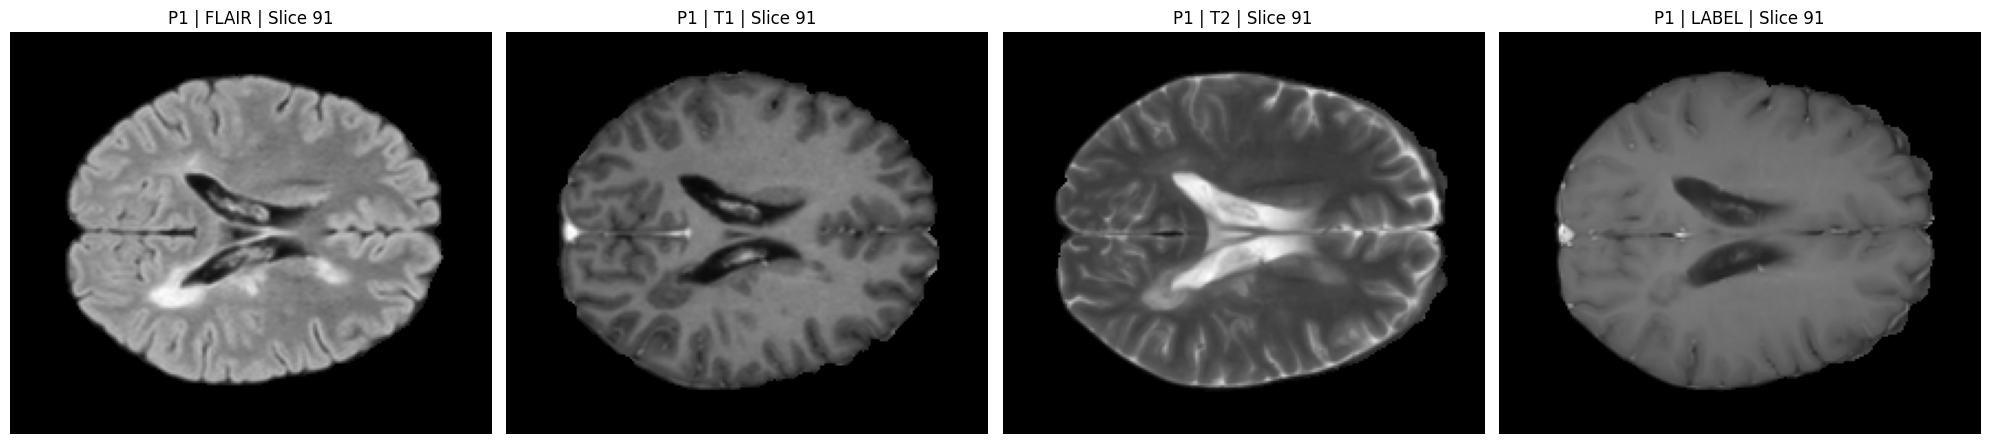

In [18]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(sample_dict, slice_idx=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    modalities = ["flair", "t1", "t2", "label"]

    for i, mod in enumerate(modalities):
        img = nib.load(sample_dict[mod]).get_fdata()
        current_slice = img.shape[2] // 2 if slice_idx is None else slice_idx
        cmap = "gray"
        axes[i].imshow(img[:, :, current_slice], cmap=cmap)
        axes[i].set_title(f"{sample_dict.get('subject', 'case')} | {mod.upper()} | Slice {current_slice}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Ensure we take a training point
if "train_files" in globals() and train_files:
    print(f"Visualizing training sample: {train_files[0]['subject']}")
    visualize_sample(train_files[0])
else:
    print("Training files not found. Falling back to testing files.")
    if "test_files" in globals() and test_files:
        visualize_sample(test_files[0])